# Inference on a single image

Load trained weights, run the model on one image, draw detected text boxes.
Edit `IMAGE_PATH` and `CKPT_PATH`, then Run All.

In [1]:
import sys
from pathlib import Path

REPO_ROOT = Path('/mnt/DATA2/dorin/handwriting-recognition/detection')
if REPO_ROOT.name == 'notebooks':
    REPO_ROOT = REPO_ROOT.parent
sys.path.insert(0, str(REPO_ROOT))

In [3]:
# IMAGE_PATH =  "/mnt/DATA2/dorin/handwriting-recognition/data/texts/20240207-07100002.jpg"
IMAGE_PATH =  "/mnt/DATA2/dorin/handwriting-recognition/data/texts/image3.jpg"

CKPT_PATH  = REPO_ROOT / 'outputs' / 'dbnetpp_r34_hwr' / 'best.pt'
CFG_PATH   = REPO_ROOT / 'config.yaml'
USE_EMA    = True     # prefer EMA weights if the checkpoint has them
DEVICE     = 'cuda'   # or 'cpu'

In [4]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from PIL import Image
from omegaconf import OmegaConf

from src.model import build_model
from src.postprocess import PostprocessConfig, decode_prob_map
from src.utils import preprocess_image_pil, draw_polygons

cfg = OmegaConf.load(CFG_PATH)
device = torch.device(DEVICE if torch.cuda.is_available() or DEVICE == 'cpu' else 'cpu')
print('device:', device)

device: cuda


In [5]:
# !pip install pyclipper
# !pip install shapely

## 1. Build model and load weights

In [6]:
model = build_model(cfg)

ckpt = torch.load(CKPT_PATH, map_location='cpu')
# state = ckpt['ema'] if (USE_EMA and ckpt.get('ema') is not None) else ckpt['model']
state = ckpt
model.load_state_dict(state)
model.eval().to(device)
print('loaded:', Path(CKPT_PATH).name, '| epoch:', ckpt.get('epoch'))

loaded: best.pt | epoch: None


In [7]:
total = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"{total/1e6:.1f}M total, {trainable/1e6:.1f}M trainable")

23.5M total, 23.5M trainable


## 2. Preprocess the image
`preprocess_image_pil` does longest-side resize + pad top-left + normalize and
returns both the tensor and the meta needed to undo the transform.

In [8]:
img = Image.open(IMAGE_PATH).convert('RGB')
# img = img.transpose(Image.ROTATE_90)
tensor, meta = preprocess_image_pil(img, image_size=cfg.data.image_size)
tensor = tensor.to(device)
print('input:', tuple(tensor.shape), '| meta:', meta)

input: (1, 3, 640, 640) | meta: {'orig_w': 640, 'orig_h': 852, 'scale': 0.7511737089201878, 'pad_left': 0, 'pad_top': 0}


## 3. Forward pass

In [9]:
with torch.no_grad():
    out = model(tensor)

prob = out['prob'][0, 0].float().cpu().numpy()   # (H, W) in [0, 1]
print('prob:', prob.shape, '| min/max:', float(prob.min()), float(prob.max()))

prob: (640, 640) | min/max: 0.0018859700066968799 0.5285475850105286


## 4. Decode polygons (uses meta to return original-image coords)

In [10]:
post_cfg = PostprocessConfig(
    thresh         = cfg.postprocess.thresh,
    box_thresh     = cfg.postprocess.box_thresh,
    unclip_ratio   = cfg.postprocess.unclip_ratio,
    max_candidates = cfg.postprocess.max_candidates,
    min_size       = cfg.postprocess.min_size,
)

boxes, scores = decode_prob_map(
    prob,
    post_cfg,
    scale         = meta['scale'],
    pad           = (meta['pad_left'], meta['pad_top']),
    original_size = (meta['orig_w'], meta['orig_h']),
)
print(f'detected {len(boxes)} boxes')

detected 0 boxes


## 5. Draw

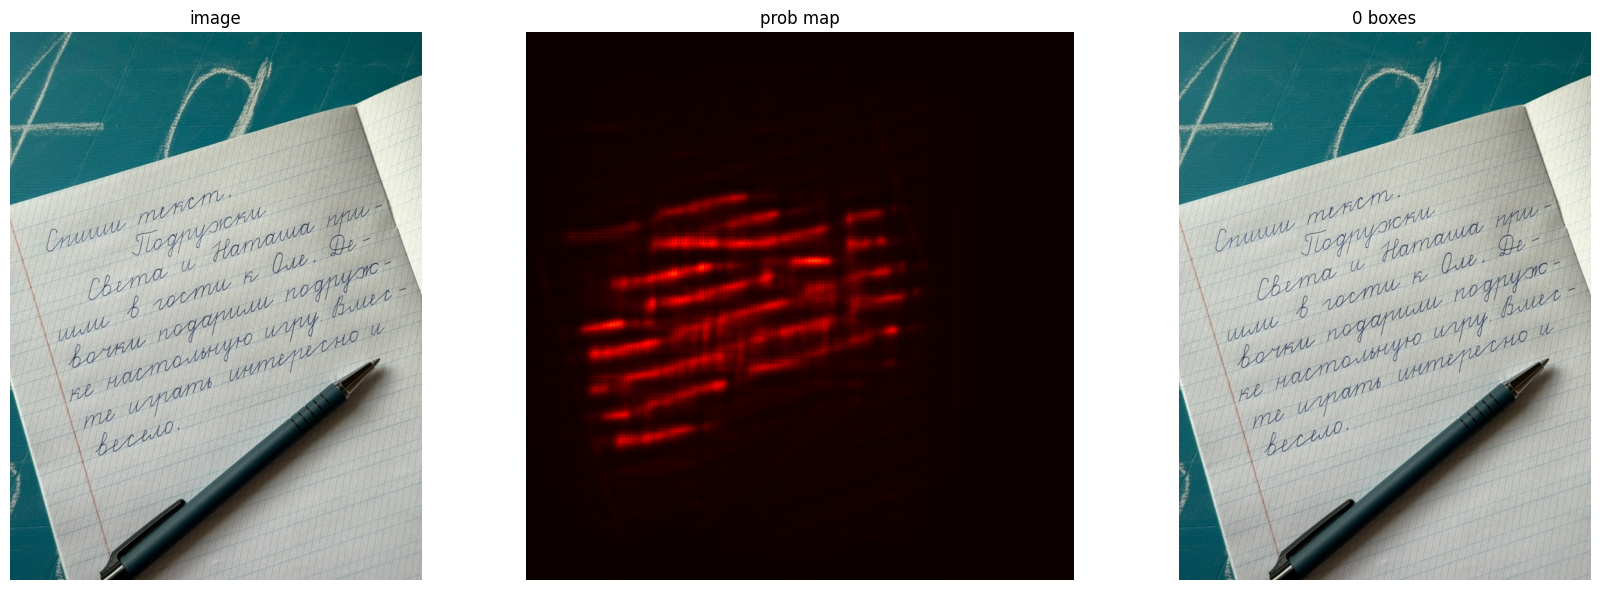

In [11]:
vis = draw_polygons(img, boxes, scores=scores, thickness=4)

fig, ax = plt.subplots(1, 3, figsize=(18, 6))
ax[0].imshow(img);                                   ax[0].set_title('image');    ax[0].axis('off')
ax[1].imshow(prob, cmap='hot', vmin=0, vmax=1);      ax[1].set_title('prob map'); ax[1].axis('off')
ax[2].imshow(vis);                                   ax[2].set_title(f'{len(boxes)} boxes'); ax[2].axis('off')
plt.tight_layout(); plt.show()

In [19]:
# from src.visualize_labels import show_from_labels

# img = show_from_labels("/mnt/DATA2/dorin/handwriting-recognition/labels/test_labels.txt", "/mnt/DATA2/seilov/hw_dataset/hw_dataset", idx=1500)
# img.show()

In [21]:
# !pip install albumentations>=1.4